<font color='IndianRed'>
<font size=9> 

**Curso Inferencia Estadística**

<font color = 'DodgerBlue'>
<font size = 5>
    
**Tarea -- regresión lineal simple -- cáncer**

---

<font color = 'deepskyblue'>
<font size = 5>

Librerías y lectura de los datos 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from plotnine import *
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("Data/cancer_mama.csv")

# Muestra las primeras rows del dataframe
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("------------------------------------------")

# Muestra las dimensiones del dataframe
print(f"Dimensiones del dataframe: {df.shape}")

print("------------------------------------------")

#Muestra las columnas del dataframe
print(df.columns)

print("------------------------------------------")

# Buscamos valores nulos en la columna de 'mean_radius'
print(f"Valores nulos en la columna 'mean_radius': {df['mean_radius'].isna().sum()}")

print("------------------------------------------")

# Buscamos valores nulos en la columna de 'mean_area'
print(f"Valores nulos en la columna 'mean_area': {df['mean_area'].isna().sum()}")

print("------------------------------------------")

# Buscamos valores nulos en la columna de 'mean_perimeter'
print(f"Valores nulos en la columna 'mean_perimeter': {df['mean_perimeter'].isna().sum()}")

print("------------------------------------------")

------------------------------------------
Dimensiones del dataframe: (569, 31)
------------------------------------------
Index(['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area',
       'mean_smoothness', 'mean_compactness', 'mean_concavity',
       'mean_concave_points', 'mean_symmetry', 'mean_fractal_dimension',
       'radius_error', 'texture_error', 'perimeter_error', 'area_error',
       'smoothness_error', 'compactness_error', 'concavity_error',
       'concave_points_error', 'symmetry_error', 'fractal_dimension_error',
       'worst_radius', 'worst_texture', 'worst_perimeter', 'worst_area',
       'worst_smoothness', 'worst_compactness', 'worst_concavity',
       'worst_concave_points', 'worst_symmetry', 'worst_fractal_dimension',
       'diagnosis'],
      dtype='object')
------------------------------------------
Valores nulos en la columna 'mean_radius': 0
------------------------------------------
Valores nulos en la columna 'mean_area': 0
----------------------

<font color = 'LightSeaGreen'>
<font size = 3>

---

**Regresión lineal 1.**

**mean_radius vs mean_area**

In [4]:
# Extraemos las molumnas 'mean_radius' y 'mean_area'
df1 = df[['mean_radius', 'mean_area']]
df1

,mean_radius,mean_area
0,17.99,1001.0
1,20.57,1326.0
2,19.69,1203.0
3,11.42,386.1
4,20.29,1297.0
...,...,...
564,21.56,1479.0
565,20.13,1261.0
566,16.60,858.1
567,20.60,1265.0


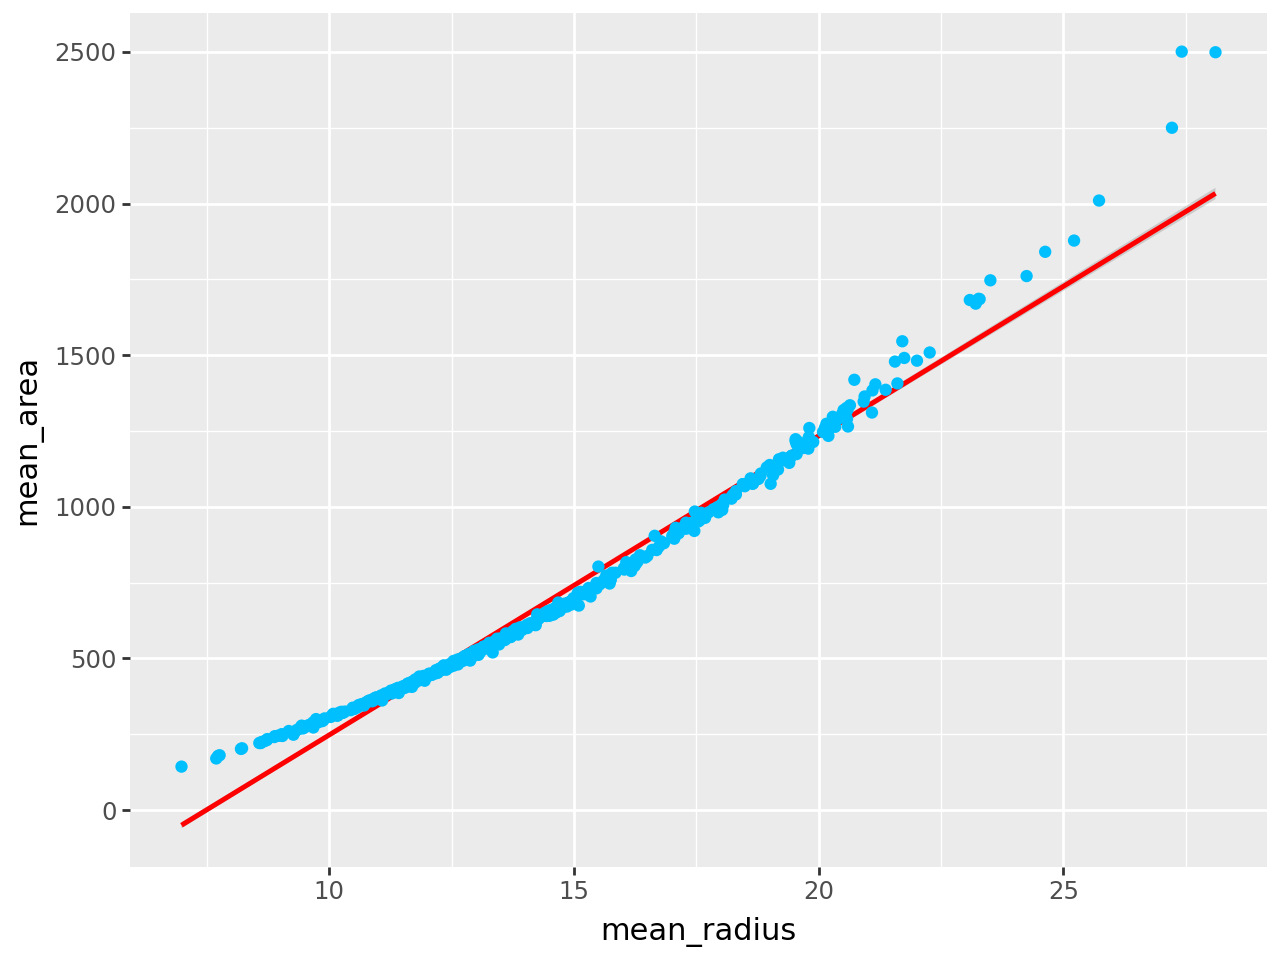

In [5]:
(ggplot(data = df1) +
     geom_smooth(mapping = aes(x = "mean_radius", y = "mean_area"), method = "lm", color = "red") + # recta de regresión
     geom_point(mapping = aes(x = "mean_radius", y = "mean_area"), color = "deepskyblue") # gráfica de los puntos
)

In [6]:
# Agregar una constante para la intercepción
X = sm.add_constant(df["mean_radius"]) # columna predictora
y = df["mean_area"] # columna objetivo

In [7]:
X

,const,mean_radius
0,1.0,17.99
1,1.0,20.57
2,1.0,19.69
3,1.0,11.42
4,1.0,20.29
...,...,...
564,1.0,21.56
565,1.0,20.13
566,1.0,16.60
567,1.0,20.60


In [8]:
y

0      1001.0
1      1326.0
2      1203.0
3       386.1
4      1297.0
        ...  
564    1479.0
565    1261.0
566     858.1
567    1265.0
568     181.0
Name: mean_area, Length: 569, dtype: float64

In [9]:
# Realiza la regresión lineal
modelo = sm.OLS(y, X).fit()

In [10]:
# Resumen general de los resultados
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              mean_area   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 2.200e+04
Date:                Tue, 21 Jan 2025   Prob (F-statistic):               0.00
Time:                        13:22:28   Log-Likelihood:                -3095.1
No. Observations:                 569   AIC:                             6194.
Df Residuals:                     567   BIC:                             6203.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -738.0367      9.679    -76.255      0.000    -757.047    -719.027
mean_radius    98.5982      0.665    148.322      0.000      97.293      99.904
==============================================================================
Omnibus:                      486.303   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15329.672
Skew:                           3.595   Prob(JB):                         0.00
Kurtosis:                      27.390   Cond. No.                         60.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color = 'LightSeaGreen'>
<font size = 3>

Observamos que los p-valores son igual a 0.

In [11]:
# Resultados -----> b = -738.036704, m = 98.598219
modelo.params

const         -738.036704
mean_radius     98.598219
dtype: float64

<font color = 'LightSeaGreen'>
<font size = 3>

Obtenemos los valores de $m = 98.598219$ y $b = -738.036704$. 

In [12]:
# Coeficiente de determinación
modelo.rsquared

np.float64(0.9748741812622022)

<font color = 'LightSeaGreen'>
<font size = 3>

Como el coeficiente de eterminación es cercano a 1, entonces esta recta nos sirve. Por lo que el modelo se ajusta bien.

Como se observa en la gráfica, para valores 'mean_area' $> 1500$ y $< 250$ la recta no se ajusta muy bien, pero para valores en entre ese intervalo si hay un buen ajuste.

In [13]:
# Intervalos de confianza de los coeficientes al 99%
modelo.conf_int(alpha = 0.01)

,0,1
const,-763.051068,-713.022340
mean_radius,96.880134,100.316304


<font color = 'LightSeaGreen'>
<font size = 3>

---

**Regresión lineal 2.**

**mean_radius vs mean_perimeter**

In [15]:
# Extraemos las molumnas 'mean_radius' y 'mean_area'
df2 = df[['mean_radius', 'mean_perimeter']]
df2

,mean_radius,mean_perimeter
0,17.99,122.80
1,20.57,132.90
2,19.69,130.00
3,11.42,77.58
4,20.29,135.10
...,...,...
564,21.56,142.00
565,20.13,131.20
566,16.60,108.30
567,20.60,140.10


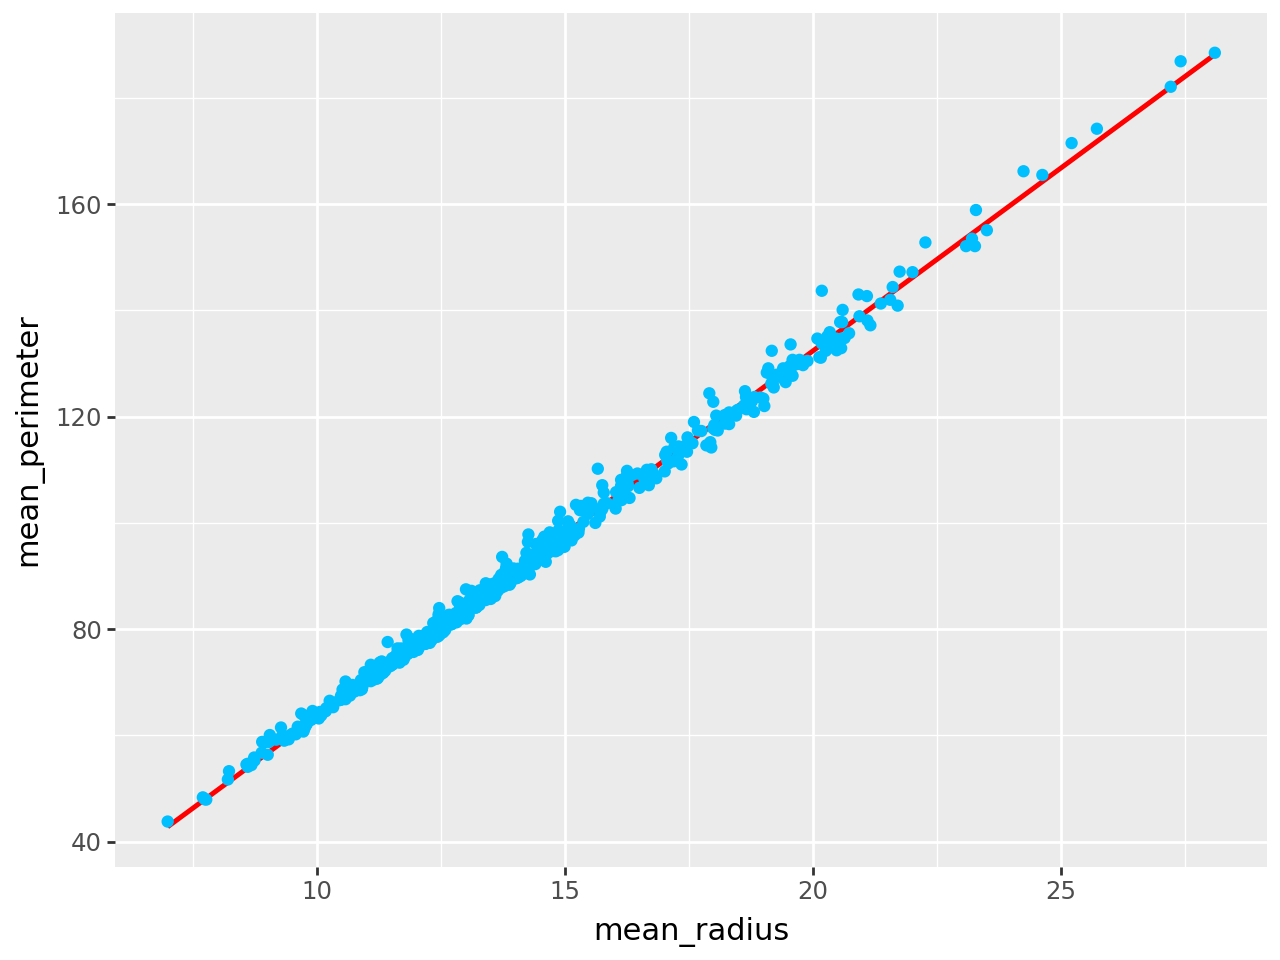

In [16]:
(ggplot(data = df2) +
     geom_smooth(mapping = aes(x = "mean_radius", y = "mean_perimeter"), method = "lm", color = "red") + # recta de regresión
     geom_point(mapping = aes(x = "mean_radius", y = "mean_perimeter"), color = "deepskyblue") # gráfica de los puntos
)

In [17]:
# Agregar una constante para la intercepción
X = sm.add_constant(df2["mean_radius"]) # columna predictora
y = df2["mean_perimeter"] # columna objetivo

In [18]:
X

,const,mean_radius
0,1.0,17.99
1,1.0,20.57
2,1.0,19.69
3,1.0,11.42
4,1.0,20.29
...,...,...
564,1.0,21.56
565,1.0,20.13
566,1.0,16.60
567,1.0,20.60


In [21]:
y

0      122.80
1      132.90
2      130.00
3       77.58
4      135.10
        ...  
564    142.00
565    131.20
566    108.30
567    140.10
568     47.92
Name: mean_perimeter, Length: 569, dtype: float64

In [22]:
# Realizar la regresión lineal
modelo = sm.OLS(y, X).fit()

In [23]:
# Resumen general de los resultados
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         mean_perimeter   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.318e+05
Date:                Tue, 21 Jan 2025   Prob (F-statistic):               0.00
Time:                        14:02:23   Log-Likelihood:                -1070.9
No. Observations:                 569   AIC:                             2146.
Df Residuals:                     567   BIC:                             2155.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.2324      0.276    -18.960      0.000      -5.774      -4.690
mean_radius     6.8804      0.019    362.988      0.000       6.843       6.918
==============================================================================
Omnibus:                      165.866   Durbin-Watson:                   1.787
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              601.949
Skew:                           1.318   Prob(JB):                    1.94e-131
Kurtosis:                       7.295   Cond. No.                         60.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<font color = 'LightSeaGreen'>
<font size = 3>

Observamos que los p-valores son igual a 0.

In [24]:
# Resultados ----> b = -5.2323, m = 6.88
modelo.params

const         -5.232389
mean_radius    6.880400
dtype: float64

<font color = 'LightSeaGreen'>
<font size = 3>

Obtenemos los valores de $m = 6.88$ y $b = -5.2323$. 

In [25]:
modelo.rsquared

np.float64(0.9957151628050925)

<font color = 'LightSeaGreen'>
<font size = 3>

Como el coeficiente de eterminación es muy cercano a 1, entonces tenemos un ajuste casi perfecto. Esto también se muestra en la gráfica, ya que los datos se ajustan muy bien a la recta de **regresión**.

In [26]:
modelo.conf_int(alpha = 0.01) # 99%

,0,1
const,-5.945649,-4.519129
mean_radius,6.831411,6.929390
